In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [3]:
data = {
    'Review': [
        "The movie was absolutely amazing! I loved the acting and the story.",
        "It was a complete waste of time. Horrible acting and very boring.",
        "The cinematography was decent, but the overall plot was just average.",
        "Wow! What a masterpiece. A must watch for everyone!",
        "I hated the ending. It ruined the whole experience for me."
    ]
}

df = pd.DataFrame(data)
df

,Review
0,The movie was absolutely amazing! I loved the ...
1,It was a complete waste of time. Horrible acti...
2,"The cinematography was decent, but the overall..."
3,Wow! What a masterpiece. A must watch for ever...
4,I hated the ending. It ruined the whole experi...


In [4]:
# Function to calculate sentiment score
def get_sentiment(text):
    scores = sia.polarity_scores(text)
    if scores['compound'] >= 0.05:
        return 'Positive'
    elif scores['compound'] <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Applying the function to our dataframe
df['Sentiment'] = df['Review'].apply(get_sentiment)
df

,Review,Sentiment
0,The movie was absolutely amazing! I loved the ...,Positive
1,It was a complete waste of time. Horrible acti...,Negative
2,"The cinematography was decent, but the overall...",Neutral
3,Wow! What a masterpiece. A must watch for ever...,Positive
4,I hated the ending. It ruined the whole experi...,Negative


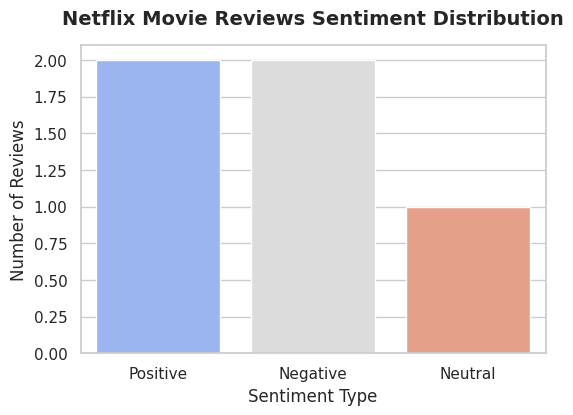

In [8]:
# Setting the style and figure size for the graph
plt.figure(figsize=(6, 4))
sns.set_theme(style="whitegrid")

# Creating a clean bar chart for sentiment counts
sns.countplot(data=df, x='Sentiment', hue='Sentiment', palette='coolwarm', legend=False)

# Adding titles and professional labels
plt.title('Netflix Movie Reviews Sentiment Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sentiment Type', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

# Displaying the final plot
plt.show()